In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Raw data from 21-Sept-2026 to 05-Oct-2026
MOVITRANS	International, truck PROSTAR	TFU128	1JOL	867284063901070

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Downloads\1JOL.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  725 non-null    str  
 1   Message  725 non-null    str  
 2   Status   725 non-null    str  
dtypes: str(3)
memory usage: 17.1 KB


In [3]:
print(raw_data.iloc[raw_data.shape[0]-1])

Created                              2026-10-01 19:39:54.951
Message    [{"Protocol":"0x2626","MessageType":"LocationA...
Status     0x2626040053002E0867284063901070001902581E0000...
Name: 724, dtype: str


In [4]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes
raw_data['Codes'].value_counts()

Codes
03    441
02    213
04     33
09     19
01     11
11      8
Name: count, dtype: int64

In [5]:
torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])

torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
engine_load=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:94])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][131:133]))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    rpm.append(int(torch_codes_0204.iloc[i,2][150:154],16))
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    engine_load.append(int(torch_codes_0204.iloc[i,2][162:164],16))
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['rpm']=rpm
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel']=remain_fuel_rate
torch_codes_0204['engine_load']=engine_load

torch_codes_0204_ordered=torch_codes_0204.sort_values('date',ascending=True)

print(torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','engine_load']])

     i_on  i_off                  io  odometer          date  ext_ps  speed  \
1      25    600                 0b0      8488  260921000632   12.78      0   
4      25    600                 0b0      8488  260921001632   12.76      0   
7      25    600                 0b0      8488  260921002632   12.77      0   
10     25    600                 0b0      8488  260921003632   12.76      0   
13     25    600                 0b0      8488  260921004632   12.77      0   
..    ...    ...                 ...       ...           ...     ...    ...   
713    25    600  0b1000000000000000      8531  261001190815    0.37      0   
716    25    600  0b1000000000000000      8531  261001191815    0.37      0   
719    25    600  0b1000000000000000      8531  261001192815    0.37      0   
722    25    600  0b1000000000000000      8531  261001193815    0.37      0   
724    25    600  0b1000000000000000      8531  261001193953    0.37      0   

      acc_fuel_c    rpm remain_fuel  gnss  cool_tem

In [6]:
torch_codes_0204_ordered.info()

<class 'pandas.DataFrame'>
Index: 246 entries, 1 to 724
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Created      246 non-null    str    
 1   Message      246 non-null    str    
 2   Status       246 non-null    str    
 3   Codes        246 non-null    str    
 4   i_on         246 non-null    int64  
 5   i_off        246 non-null    int64  
 6   io           246 non-null    str    
 7   odometer     246 non-null    int64  
 8   date         246 non-null    str    
 9   ext_ps       246 non-null    float64
 10  speed        246 non-null    int64  
 11  gnss         246 non-null    int64  
 12  acc_fuel_c   246 non-null    float64
 13  rpm          246 non-null    int64  
 14  cool_temp    246 non-null    int64  
 15  remain_fuel  246 non-null    str    
 16  engine_load  246 non-null    int64  
dtypes: float64(2), int64(8), str(7)
memory usage: 34.6 KB


In [7]:
df=torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','Status','engine_load']]
df.info()

<class 'pandas.DataFrame'>
Index: 246 entries, 1 to 724
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         246 non-null    int64  
 1   i_off        246 non-null    int64  
 2   io           246 non-null    str    
 3   odometer     246 non-null    int64  
 4   date         246 non-null    str    
 5   ext_ps       246 non-null    float64
 6   speed        246 non-null    int64  
 7   acc_fuel_c   246 non-null    float64
 8   rpm          246 non-null    int64  
 9   remain_fuel  246 non-null    str    
 10  gnss         246 non-null    int64  
 11  cool_temp    246 non-null    int64  
 12  Status       246 non-null    str    
 13  engine_load  246 non-null    int64  
dtypes: float64(2), int64(8), str(4)
memory usage: 28.8 KB


Odometer

8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8488
8496
8496
8503
8503
8531
8531
8531
8531
8531
8531


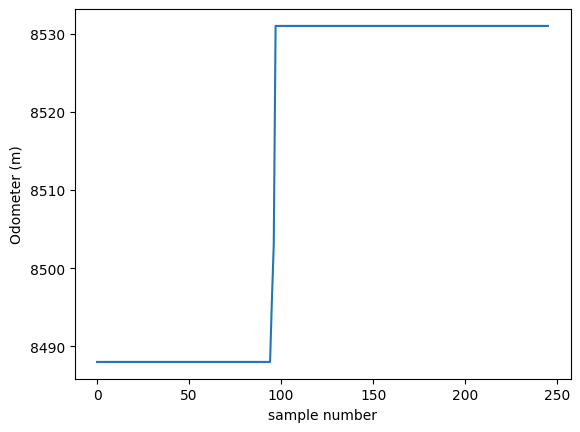

In [8]:
odometer=pd.DataFrame()
odometer_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    print(int(df.iloc[i,3]))
    #if int(df.iloc[i,3]>80000000):
    print(int(df.iloc[i,3]))
    status.append(df.iloc[i,12])
    odometer_data.append(int(df.iloc[i,3]))
    date.append(df.iloc[i,4])
    x_axis.append(i)
try:
    print(max(odometer_data),min(odometer_data))
except:
    print(df.iloc[i,3])

odometer['sample_number']=x_axis
odometer['odometer']=odometer_data
odometer['date']=date
odometer['status']=status

plt.ylabel("Odometer (m)")
plt.xlabel('sample number')
#plt.xticks(range(0,5572,100),rotation=90)
plt.plot(x_axis,odometer_data)

#odometer.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\odometer.csv')

Speed

31 0


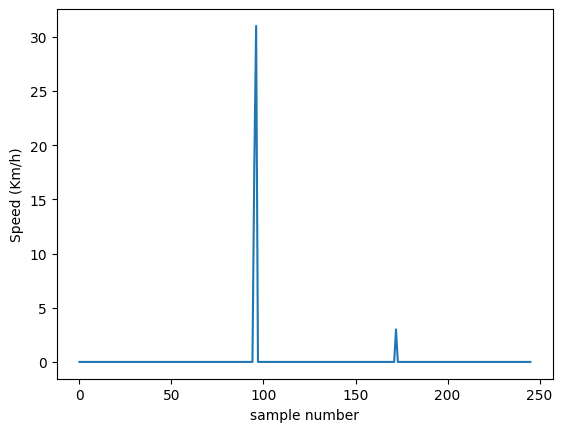

In [9]:
speed=pd.DataFrame()
speed_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):                        
        status.append(df.iloc[i,12])
        speed_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(speed_data),min(speed_data))
speed['sample_number']=x_axis
speed['speed']=speed_data
speed['status']=status

plt.ylabel("Speed (Km/h)")
plt.xlabel('sample number')
plt.plot(x_axis,speed_data)

#speed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\speed.csv')

RPM

0 0


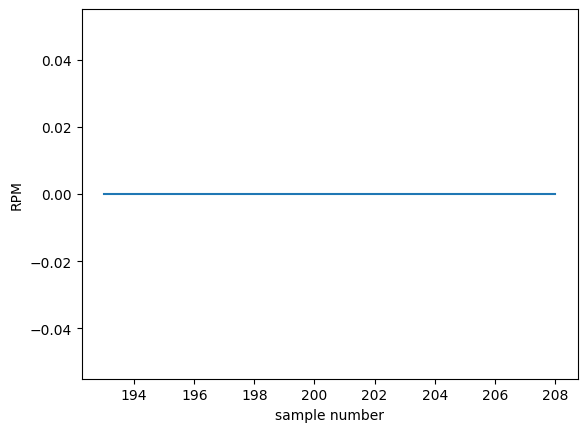

In [10]:
rpm=pd.DataFrame()
rpm_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
        if df.iloc[i,8]<65535:
                status.append(df.iloc[i,12])
                rpm_data.append(int(df.iloc[i,8]))
                date.append(df.iloc[i,4])
                x_axis.append(i)            

print(max(rpm_data),min(rpm_data))
rpm['sample_number']=x_axis
rpm['rpm']=rpm_data
rpm['status']=status

plt.ylabel("RPM")
plt.xlabel('sample number')
plt.plot(x_axis,rpm_data)
#rpm.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rpm.csv')

Fuel

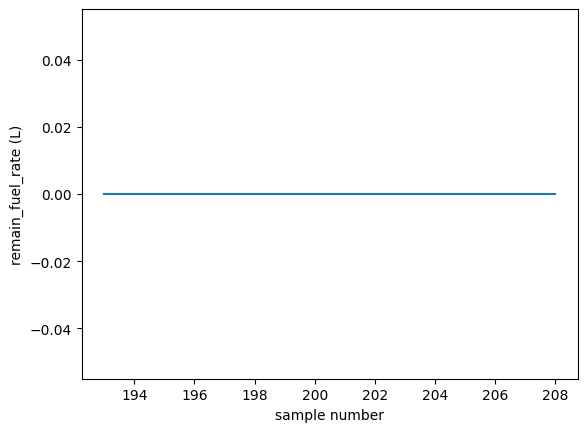

In [11]:
rfl=pd.DataFrame()
fuel_data=[]
x_axis=[]
date=[]
status=[]
status_aux=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])

plt.plot(x_axis,fuel_data)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

rfl['fuel_data']=fuel_data
rfl['date']=date
rfl['raw_data']=status
#rfl.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rfl_1i1v.csv',sep=',')

Cooling fluid Temperature 

0 0


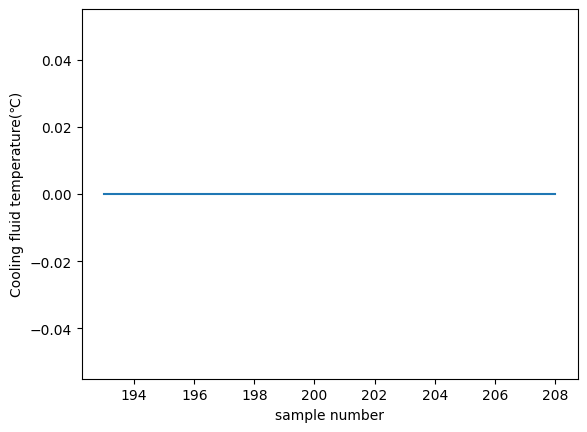

In [12]:
temp=pd.DataFrame()
temp_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,11]!=255:               
        aux_data=df.iloc[i,11]
        status.append(df.iloc[i,12])
        temp_data.append(df.iloc[i,11]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
temp['sample_number']=x_axis
temp['date']=date
temp['temp']=temp_data
temp['status']=status

plt.ylabel("Cooling fluid temperature(℃)")
plt.xlabel('sample number')
plt.plot(x_axis,temp_data)

#temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\temp.csv')

Engine load

0 0


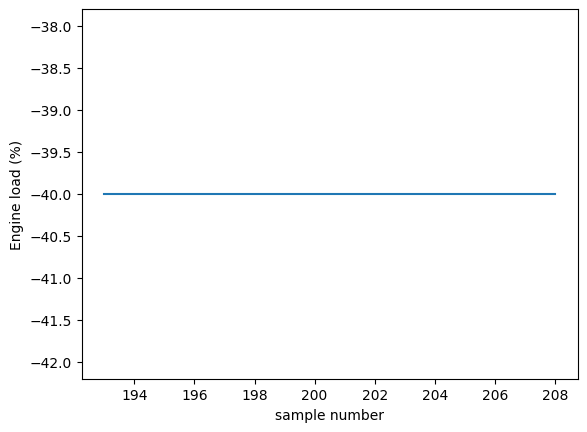

In [13]:
engine_load=pd.DataFrame()
engine_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,13]!=255:               
        aux_data=df.iloc[i,13]
        status.append(df.iloc[i,12])
        engine_data.append(df.iloc[i,13]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
engine_load['sample_number']=x_axis
engine_load['date']=date
engine_load['engine load %']=engine_data
engine_load['status']=status

plt.ylabel("Engine load (%)")
plt.xlabel('sample number')
plt.plot(x_axis,engine_data)

#temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\engine.csv')